## The Mathematics of Gradient Descent (Deriving the Engine)

To understand Gradient Descent, we have to use Calculus—specifically, partial derivatives and the Chain Rule. Our goal is to find the exact slope of the error curve so we know which way is "downhill."

### Step 1: The Foundation

We start with our two core equations.

**The Prediction (Hypothesis):**

$\hat{y} = mx + b$

**The Objective (Loss Function):**

We use Mean Squared Error (MSE):

$$L(m, b) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

If we substitute our prediction equation into our loss function, we get the master equation we need to optimize:

$$L(m, b) = \frac{1}{n} \sum_{i=1}^n (y_i - (mx_i + b))^2$$

### Step 2: The Calculus (Partial Derivatives)

Because our loss function is a 3D bowl shaped by two variables ($m$ and $b$), we can't take a standard derivative. We have to take **Partial Derivatives**. This means we treat one variable as a constant while we calculate the derivative for the other.

To do this, we use the **Chain Rule** from calculus: Take the derivative of the outside function, multiplied by the derivative of the inside function.

#### A. Deriving with respect to the Intercept ($b$):

We want to know how much the Loss changes if we take a tiny step in the $b$ direction.

$$\frac{\partial L}{\partial b}$$

Outside derivative: The squared exponent $2$ comes down to the front.

$$= \frac{2}{n} \sum_{i=1}^n (y_i - (mx_i + b))^1$$

Inside derivative: We look inside the parentheses $(y_i - mx_i - b)$. The derivative of $-b$ with respect to $b$ is simply $-1$. (The other terms become $0$ because we treat them as constants).

Multiply them together:

$$\frac{\partial L}{\partial b} = \frac{2}{n} \sum_{i=1}^n (y_i - \hat{y}_i) \cdot (-1)$$

Final equation for the $b$ gradient:

$$\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^n (y_i - \hat{y}_i)$$

#### B. Deriving with respect to the Slope ($m$):

Now, how much does the Loss change if we take a tiny step in the $m$ direction?

$$\frac{\partial L}{\partial m}$$

Outside derivative: The exact same as before.

$$= \frac{2}{n} \sum_{i=1}^n (y_i - (mx_i + b))^1$$

Inside derivative: We look inside the parentheses $(y_i - mx_i - b)$. The derivative of $-mx_i$ with respect to $m$ is $-x_i$.

Multiply them together:

$$\frac{\partial L}{\partial m} = \frac{2}{n} \sum_{i=1}^n (y_i - \hat{y}_i) \cdot (-x_i)$$

Final equation for the $m$ gradient:

$$\frac{\partial L}{\partial m} = -\frac{2}{n} \sum_{i=1}^n x_i(y_i - \hat{y}_i)$$

### Step 3: The Update Rule

Now that we have the exact mathematical slope for both $m$ and $b$, we use them to update our current position.

We subtract the gradient (multiplied by our Learning Rate, $\eta$) from our old weights to step downhill.

$$b_{new} = b_{old} - \eta \cdot \frac{\partial L}{\partial b}$$

$$m_{new} = m_{old} - \eta \cdot \frac{\partial L}{\partial m}$$

This is the pure mathematical engine. When we write the Python code later, we aren't using libraries; we are just going to write a for loop that runs those exact $\frac{\partial L}{\partial b}$ and $\frac{\partial L}{\partial m}$ equations over and over again.

# Gradient Descent Custom in 1-D when taking m as constant and b value variable

Final Intercept (b) after 50 epochs: -2.2957


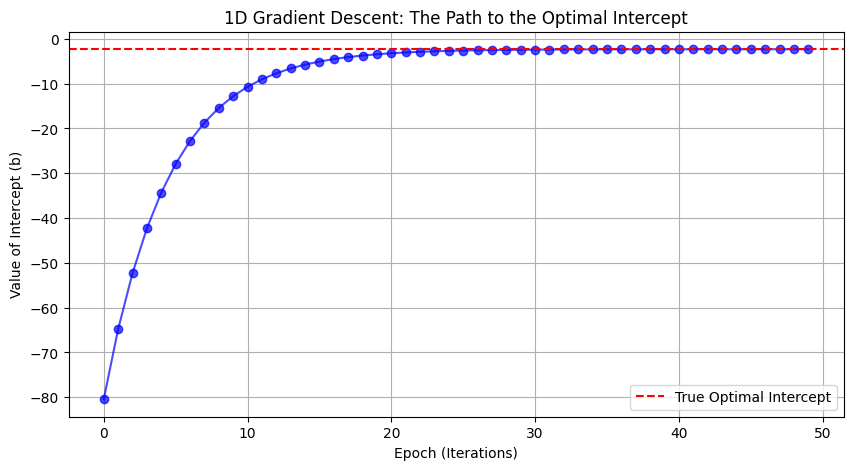

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression


# 1. GENERATE DATA AND LOCK THE SLOPE
# We create a simple dataset with 1 feature
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

# We use the known perfect slope to isolate 'b' for this experiment
m = 27.82
b_current = -100.0  # We start our intercept guess completely wrong

# 2. HYPERPARAMETERS
learning_rate = 0.1
epochs = 50
history = [] # To track our path down the bowl

# 3. THE 1D GRADIENT DESCENT ENGINE
n = X.shape[0]

for i in range(epochs):
    # Step A: Make predictions with the current intercept
    y_pred = (m * X.ravel()) + b_current

    # Step B: Calculate the derivative (The compass)
    # Formula: -2/n * sum(y - y_pred)
    loss_derivative_b = -2 * np.mean(y - y_pred)

    # Step C: The Update Rule (Taking the step)
    b_current = b_current - (learning_rate * loss_derivative_b)

    # Save the current position for our graph
    history.append(b_current)

print(f"Final Intercept (b) after {epochs} epochs: {b_current:.4f}")

# 4. VISUALIZING THE LEARNING PATH
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), history, marker='o', color='blue', alpha=0.7)

# Draw a line showing the perfect mathematical bottom
perfect_b = -2.29 # (Pre-calculated via OLS for reference)
plt.axhline(perfect_b, color='red', linestyle='--', label='True Optimal Intercept')

plt.title('1D Gradient Descent: The Path to the Optimal Intercept')
plt.xlabel('Epoch (Iterations)')
plt.ylabel('Value of Intercept (b)')
plt.legend()
plt.grid(True)
plt.show()